# Notebook to make Figure 12 (Appendix C): MaxL Finding

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

import sys
sys.path.append('../utils')
import plot_utils

## Setup

Load data

In [2]:
true_vs_maxL = np.load('../data/maxL_vs_true_3pops_appendix.npz', allow_pickle=True)['arr_0'].item()
maxL_method_comparison = np.load('../data/maxL_method_comparison_appendix.npz', allow_pickle=True)['arr_0'].item()

Plotting aesthetics, etc

In [3]:
population_labels = ['example population 1', 'example population 2',  'example population 3']
colors = ['C0', 'C3', '#41426D']

plt.rcParams.update({
    "axes.labelsize": 14,
})

## Make figures

Left subplot

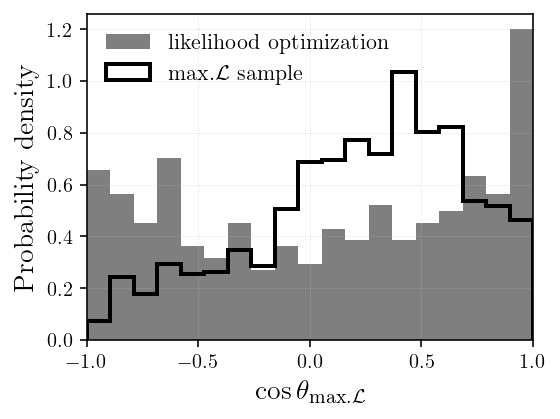

In [4]:
plt.figure(figsize=(4,3))

b = np.linspace(-1,1,20)
plt.hist(
    maxL_method_comparison['optimization'], bins=b, color='k', density=True, alpha=0.5, 
    label='likelihood optimization'
)
plt.hist(
    maxL_method_comparison['sample'], color='k', bins=b, density=True, histtype='step', lw=2, 
    label=r'$\mathrm{max}.\mathcal{L}$ sample'
)
plt.legend(fontsize=11, frameon=False)
plt.grid(color='silver', ls=':', alpha=0.5)
plt.xlabel(plot_utils.GWTC4_labels_data_vs_event['tilt']['data']['label'])
plt.ylabel(r'Probability density')

plt.xlim(-1,1)
plt.savefig('figure_12a.png',dpi=300,bbox_inches='tight')
plt.show()

Middle and right subplots

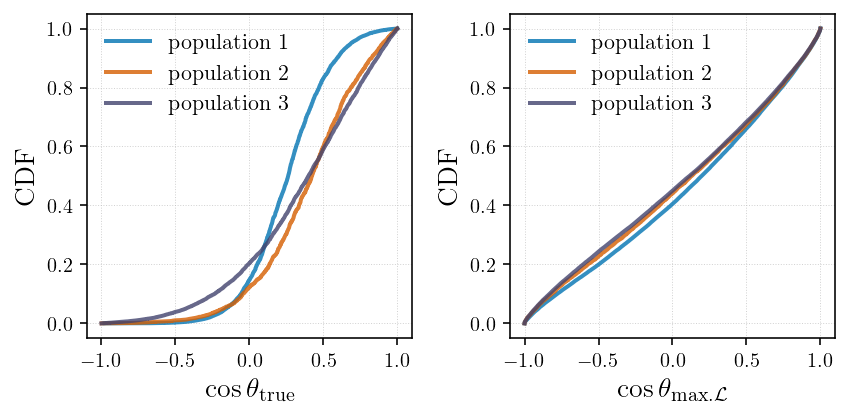

In [5]:
fig, axes = plt.subplots(1,2, figsize=(6, 3))

for i,p in enumerate(population_labels):     
    maxL_cos_theta1 = true_vs_maxL[p]['maxL_costheta']
    true_cos_theta1 = true_vs_maxL[p]['true_costheta']
    
    lbl = population_labels[i].split('example ')[-1]
    kws = dict(lw=2, alpha=0.8, label=lbl, color=colors[i])
        
    axes[0].plot(np.sort(true_cos_theta1), np.linspace(0,1,len(true_cos_theta1)), **kws)
    axes[1].plot(np.sort(maxL_cos_theta1), np.linspace(0,1,len(maxL_cos_theta1)), **kws)
    
    axes[0].set_xlabel(plot_utils.GWTC4_labels_data_vs_event['tilt']['event']['label'])
    axes[1].set_xlabel(plot_utils.GWTC4_labels_data_vs_event['tilt']['data']['label'])

for ax in axes:
    ax.grid()
    ax.legend(fontsize=11, frameon=False)
    ax.set_ylabel('CDF')
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

plt.savefig('figure_12b.png',dpi=400,bbox_inches='tight')
plt.show()